# Chapter 5: Well Performance and Artificial Lift

This notebook covers well performance analysis using NeqSim's `PipeBeggsAndBrills` model:
- Vertical Lift Performance (VLP) curves at different tubing sizes
- Operating point determination (IPR vs VLP intersection)
- Gas lift optimization concepts
- Effect of water cut on wellhead pressure

NeqSim provides rigorous multiphase pipe flow calculations using the Beggs & Brill correlation.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch05_well_performance_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NeqSim class imports
Stream = jneqsim.process.equipment.stream.Stream
PipeBeggsAndBrills = jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 7)})

## Create Production Fluid

A typical oil well production fluid with gas, oil, and water components.

In [3]:
def create_well_fluid(water_fraction=0.0):
    """Create production fluid with optional water cut."""
    T_bh_K = 273.15 + 80.0  # Bottomhole temperature
    P_bh_bara = 200.0  # Bottomhole pressure

    fluid = SystemSrkEos(T_bh_K, P_bh_bara)
    fluid.addComponent("nitrogen", 0.3)
    fluid.addComponent("CO2", 1.0)
    fluid.addComponent("methane", 60.0)
    fluid.addComponent("ethane", 8.0)
    fluid.addComponent("propane", 5.0)
    fluid.addComponent("i-butane", 1.5)
    fluid.addComponent("n-butane", 2.5)
    fluid.addComponent("i-pentane", 1.0)
    fluid.addComponent("n-pentane", 1.0)
    fluid.addComponent("n-hexane", 3.0)
    fluid.addComponent("n-heptane", 5.0)
    fluid.addComponent("n-octane", 4.0)
    fluid.addComponent("n-nonane", 2.0)
    if water_fraction > 0.0:
        # Add water as a fraction of total moles
        hc_total = 94.3  # sum of HC components above
        water_moles = hc_total * water_fraction / (1.0 - water_fraction)
        fluid.addComponent("water", water_moles)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

# Test the base fluid
test_fluid = create_well_fluid()
ops = ThermodynamicOperations(test_fluid)
ops.TPflash()
test_fluid.initProperties()
print(f"Phases: {test_fluid.getNumberOfPhases()}")
print(f"Gas density: {test_fluid.getPhase('gas').getDensity('kg/m3'):.2f} kg/m3")

Phases: 2
Gas density: 239.14 kg/m3


## Figure 1: Vertical Lift Performance (VLP) Curves

VLP curves show the relationship between bottomhole flowing pressure and production rate
for different tubing diameters. Larger tubing reduces friction but may cause velocity issues
(heading, liquid loading).

Infeasible trial at 45.91 t/hr: java.lang.RuntimeException: Failed to run unit operation wellbore
Infeasible trial at 52.73 t/hr: java.lang.RuntimeException: Failed to run unit operation wellbore
Infeasible trial at 59.55 t/hr: java.lang.RuntimeException: Failed to run unit operation wellbore
Infeasible trial at 66.36 t/hr: java.lang.RuntimeException: Failed to run unit operation wellbore
Infeasible trial at 73.18 t/hr: java.lang.RuntimeException: Failed to run unit operation wellbore
Infeasible trial at 80.00 t/hr: java.lang.RuntimeException: Failed to run unit operation wellbore
Figure 1 saved.


ch05_well_performance_figures.ipynb:cell6:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


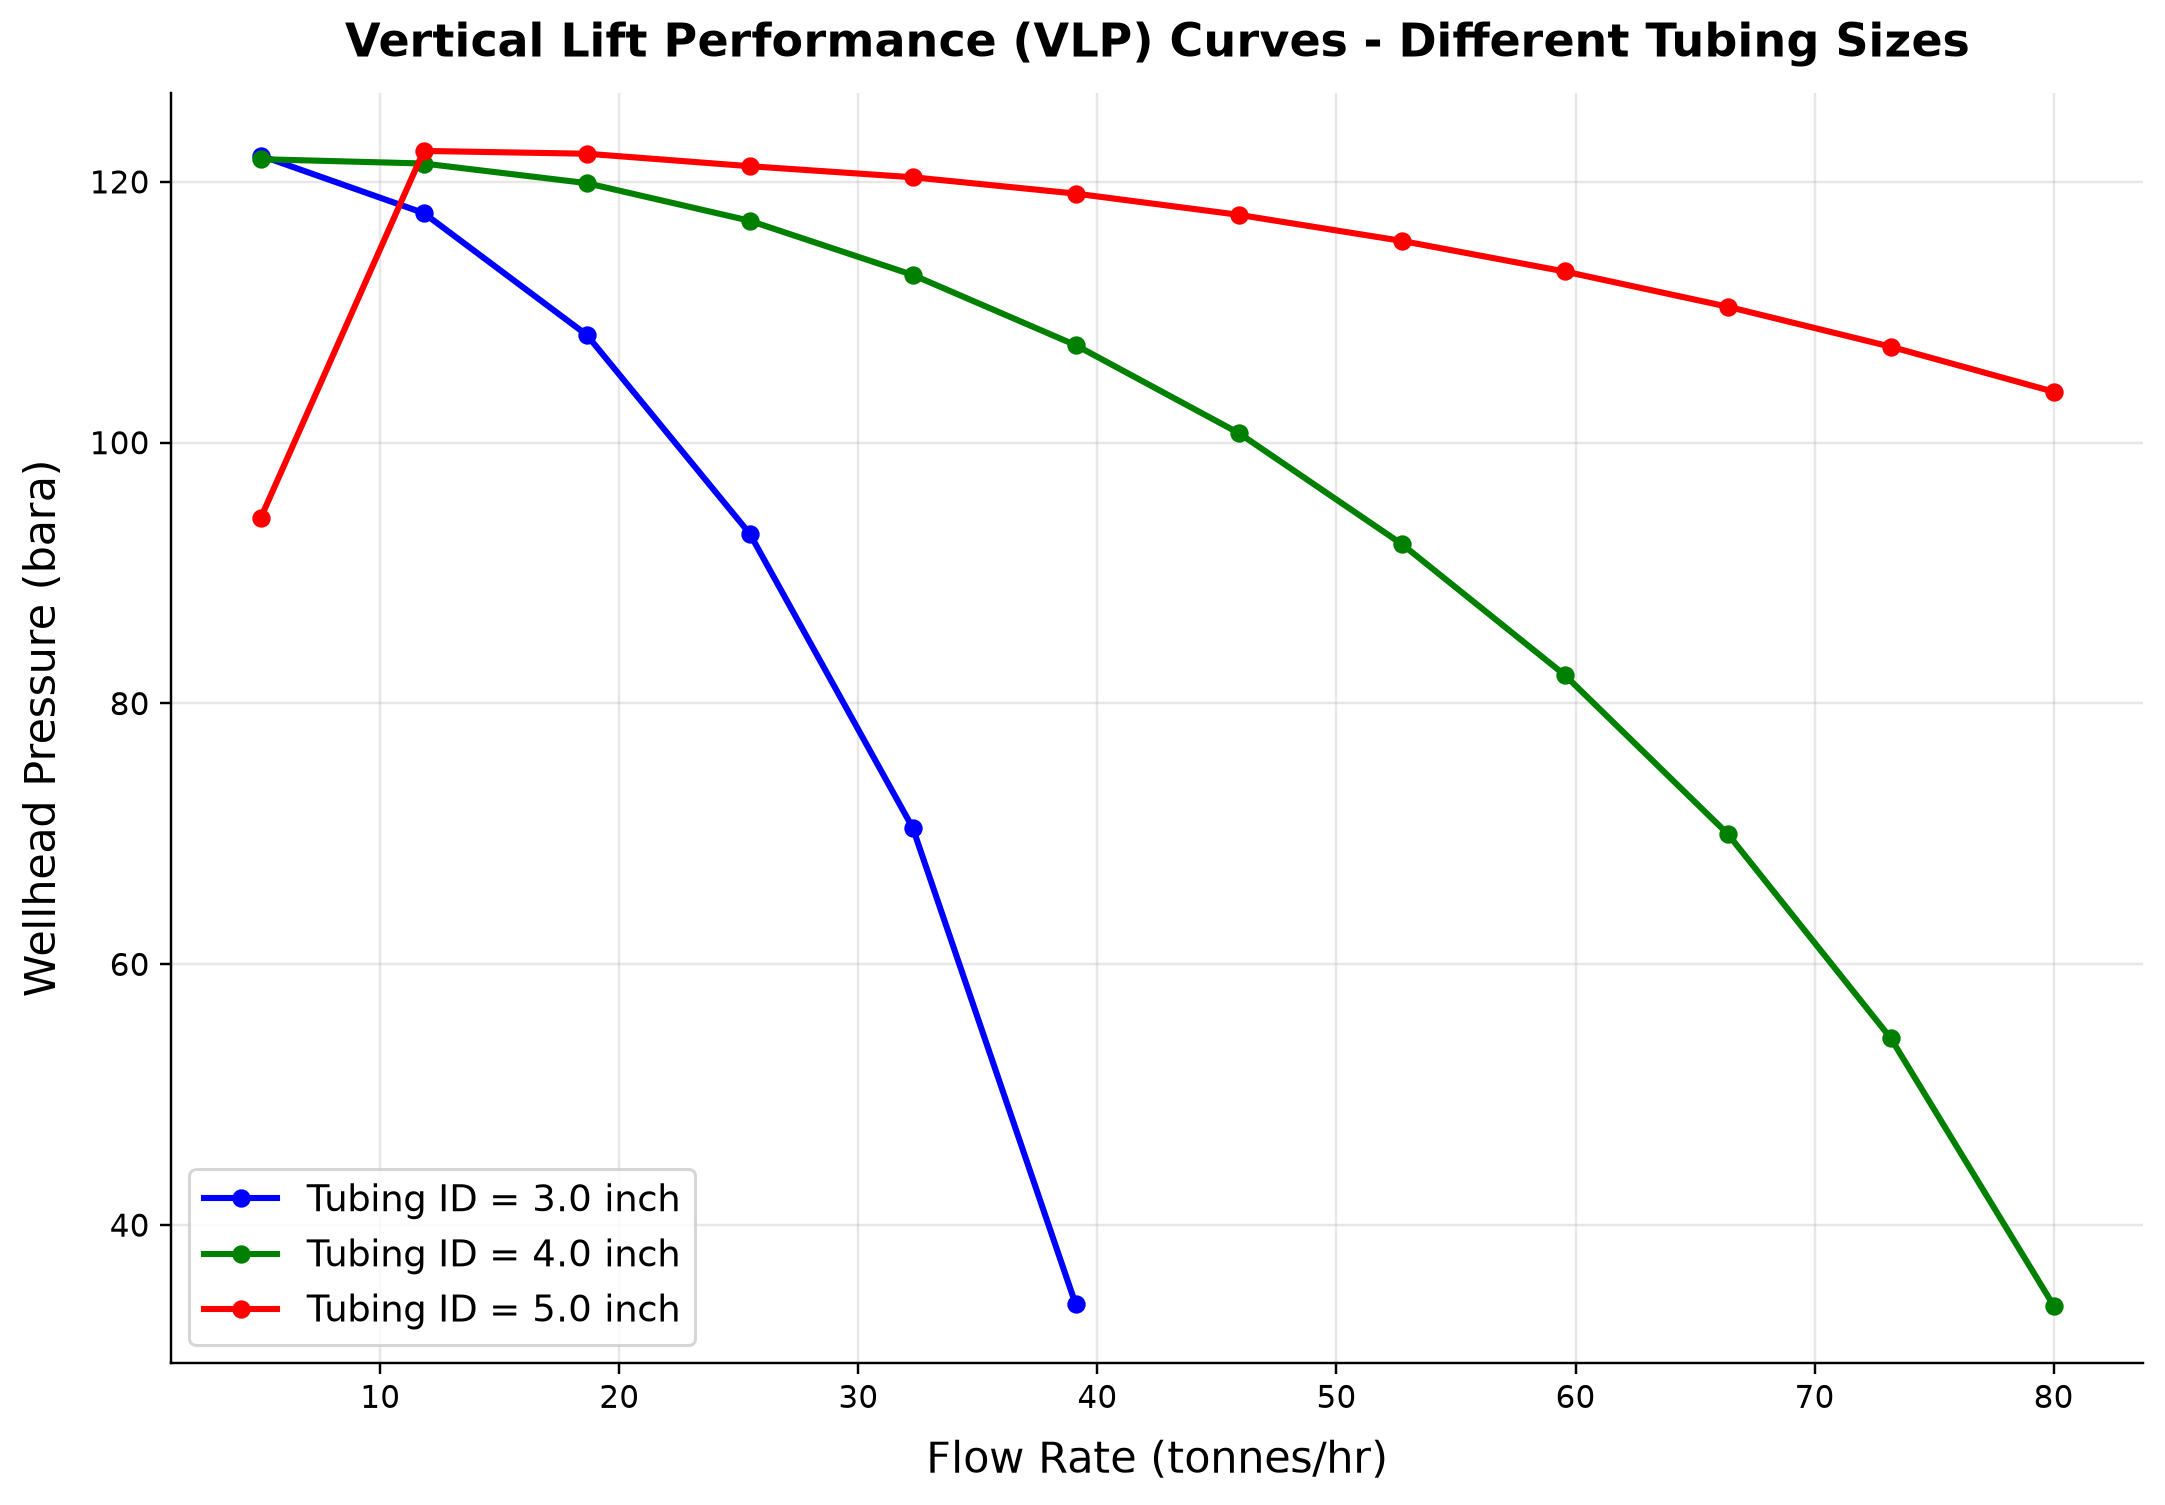

In [4]:
# Wellbore parameters
well_depth = 2500.0  # m
roughness = 2.5e-5   # m
diameters = [0.076, 0.10, 0.127]  # 3", 4", 5" tubing IDs in meters
diameter_labels = ['3.0 inch', '4.0 inch', '5.0 inch']
colors = ['blue', 'green', 'red']

# Flow rates to evaluate (kg/hr)
flow_rates = np.linspace(5000, 80000, 12)

fig, ax = plt.subplots(figsize=(10, 7))

for i, (diam, label, color) in enumerate(zip(diameters, diameter_labels, colors)):
    pwf_values = []
    valid_rates = []

    for rate in flow_rates:
        try:
            fluid = create_well_fluid()
            feed = Stream("well feed", fluid)
            feed.setFlowRate(float(rate), "kg/hr")
            feed.setTemperature(273.15 + 80.0, "K")
            feed.setPressure(200.0, "bara")

            pipe = PipeBeggsAndBrills("wellbore", feed)
            pipe.setPipeWallRoughness(roughness)
            pipe.setLength(well_depth)
            pipe.setElevation(well_depth)  # outlet is above inlet
            pipe.setDiameter(diam)

            process = ProcessSystem()
            process.add(feed)
            process.add(pipe)
            process.run()

            p_wh = pipe.getOutletStream().getPressure("bara")
            if p_wh > 5.0:  # Only valid if wellhead pressure is reasonable
                pwf_values.append(p_wh)
                valid_rates.append(rate / 1000.0)  # Convert to tonnes/hr
        except Exception as e:
            print(f'Infeasible trial at {rate / 1000:.2f} t/hr: {e}')

    if valid_rates:
        ax.plot(valid_rates, pwf_values, '-o', color=color, linewidth=2, markersize=5,
                label=f'Tubing ID = {label}')

ax.set_xlabel('Flow Rate (tonnes/hr)', fontsize=14)
ax.set_ylabel('Wellhead Pressure (bara)', fontsize=14)
ax.set_title('Vertical Lift Performance (VLP) Curves - Different Tubing Sizes', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch05_fig01_vlp_curves.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

**Executed-figure discussion.** Tubing ID = 3.0 inch: wellhead pressure spans 33.92–122 bara across the plotted cases. Tubing ID = 4.0 inch: wellhead pressure spans 33.83–121.7 bara across the plotted cases.

Tubing pressure loss combines hydrostatic head, wall friction and acceleration; changing diameter alters friction and liquid transport. A diameter that reduces friction at high rate may increase liquid loading or change the low-rate operating branch. Compare feasible IPR intersections for each diameter and reject trials with nonpositive outlet pressure or inconsistent upward elevation sign.


## Figure 2: Operating Point (IPR vs VLP Intersection)

The well operating point is where the IPR and VLP curves intersect. The IPR describes
the reservoir's ability to deliver fluid, while the VLP describes the tubing's ability
to lift it.

Rate 70.0 t/hr is infeasible at its IPR pressure: java.lang.RuntimeException: neqsim.util.exception.InvalidOutputException: PipeBeggsAndBrills:run: calcOutletPressure - output pressure out - Outlet pressure is negative-20.76146503266993
Rate 75.0 t/hr is infeasible at its IPR pressure: java.lang.RuntimeException: neqsim.util.exception.InvalidOutputException: PipeBeggsAndBrills:run: calcOutletPressure - output pressure out - Outlet pressure is negative-78.35061734338554
Rate 80.0 t/hr is infeasible at its IPR pressure: java.lang.RuntimeException: neqsim.util.exception.InvalidOutputException: PipeBeggsAndBrills:run: calcOutletPressure - output pressure out - Outlet pressure is negative-111.32237515775017
Rate 85.0 t/hr is infeasible at its IPR pressure: java.lang.RuntimeException: neqsim.util.exception.InvalidOutputException: PipeBeggsAndBrills:run: calcOutletPressure - output pressure out - Outlet pressure is negative-51.482056263333305
Rate 90.0 t/hr is infeasible at its IPR pressure: 

ch05_well_performance_figures.ipynb:cell8:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


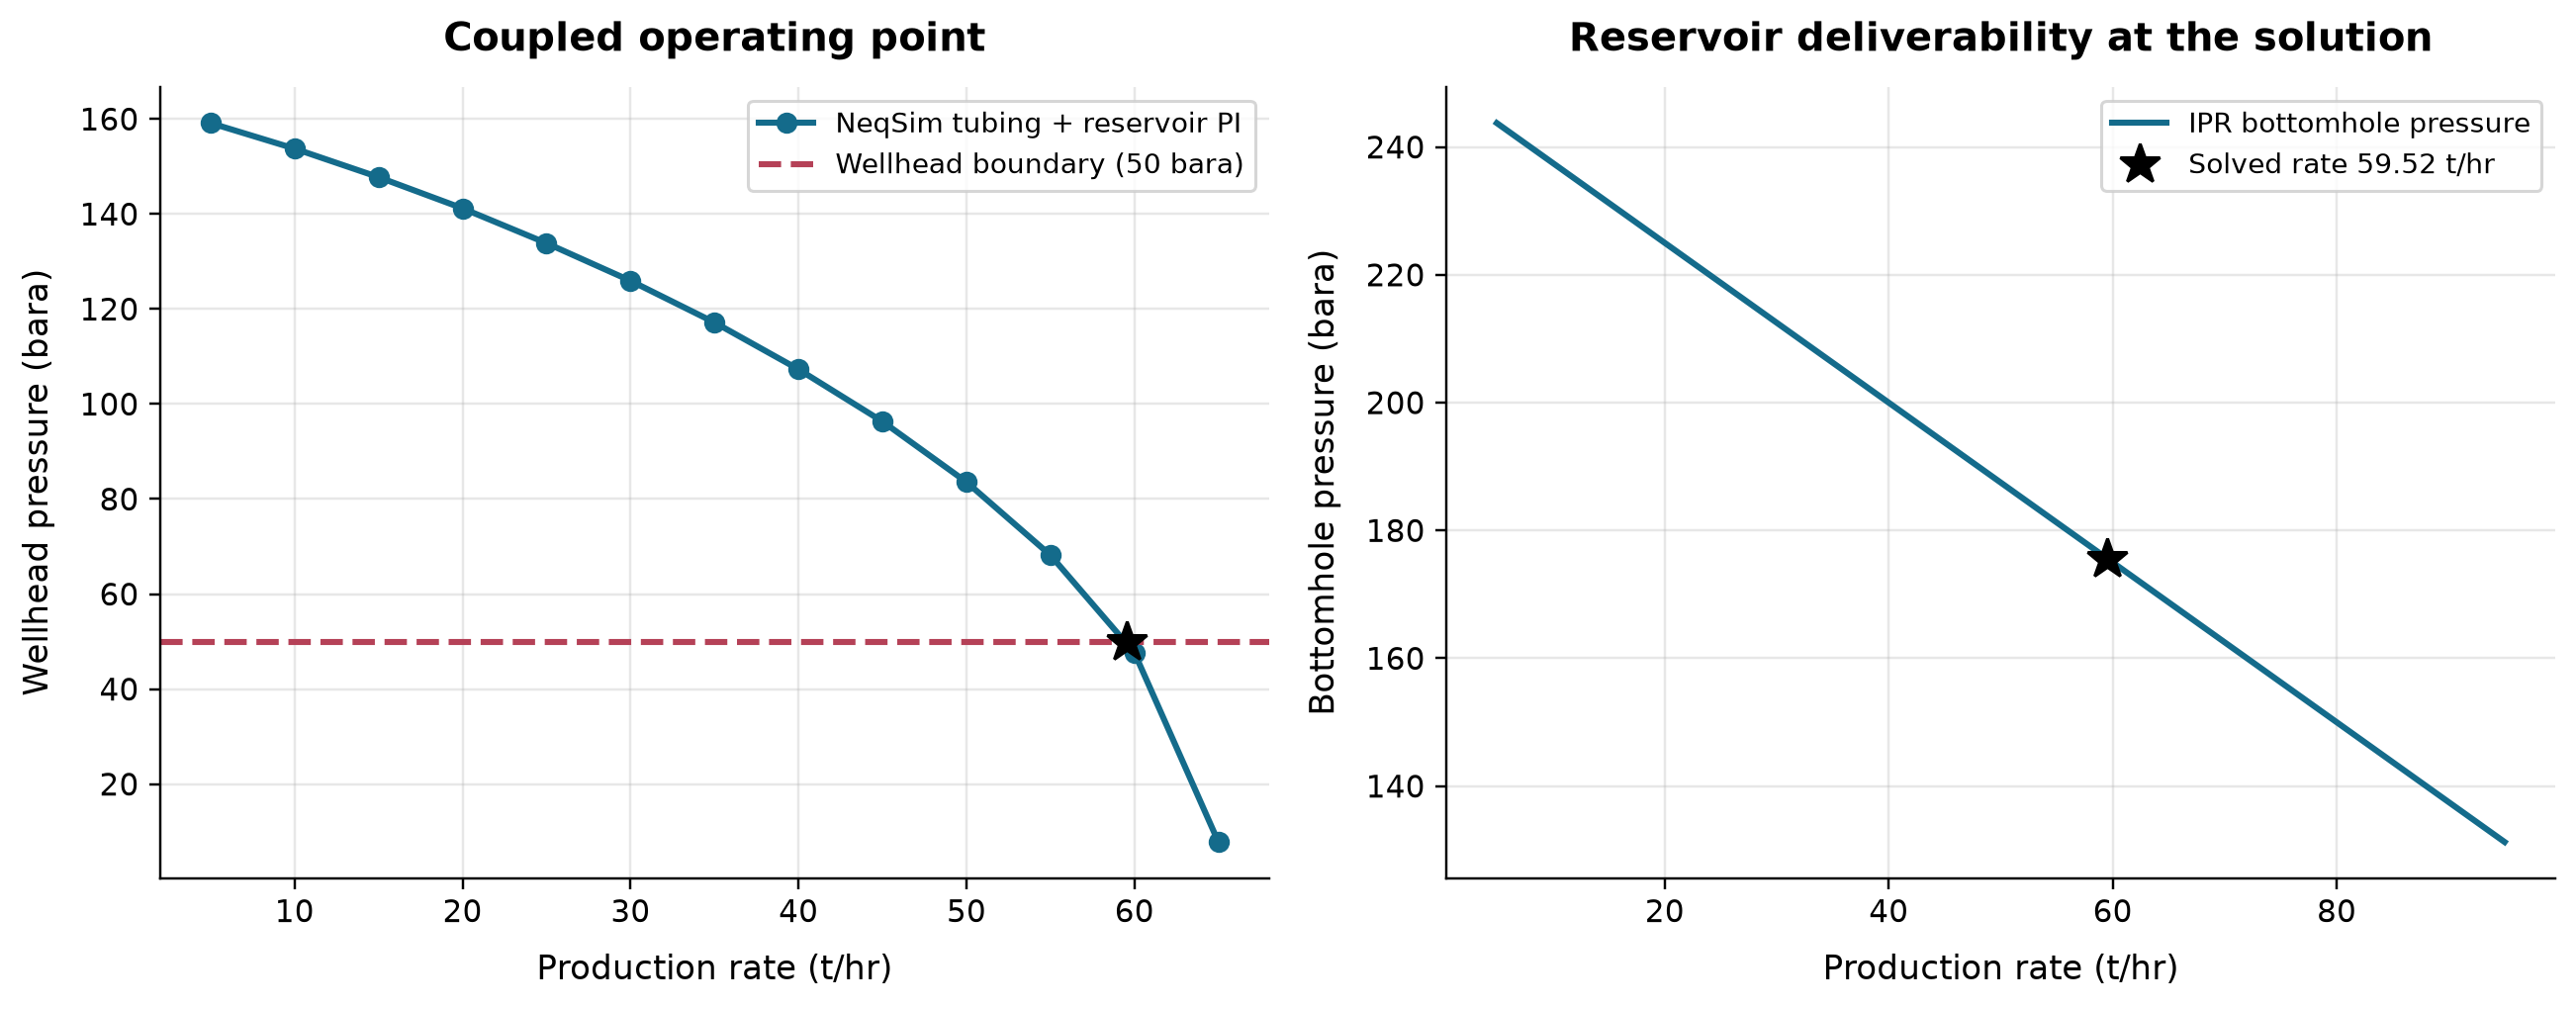

In [5]:
# Couple IPR to the actual NeqSim wellhead-pressure response.
# For each rate, the reservoir PI supplies BHP; the tubing must deliver >=50 bara.
from scipy.optimize import brentq
P_res = 250.0  # bara
PI = 0.8  # tonnes/hr/bar
P_wh_target = 50.0  # bara
def wellhead_at_rate(rate_tph, bottomhole_pressure):
    fluid_trial = create_well_fluid()
    feed_trial = Stream("Nodal feed", fluid_trial)
    feed_trial.setFlowRate(float(rate_tph * 1000.0), "kg/hr")
    feed_trial.setPressure(float(bottomhole_pressure), "bara")
    feed_trial.setTemperature(80.0, "C")
    tubing_trial = PipeBeggsAndBrills("Nodal tubing", feed_trial)
    tubing_trial.setPipeWallRoughness(2.5e-5)
    tubing_trial.setLength(2500.0)
    tubing_trial.setElevation(2500.0)
    tubing_trial.setDiameter(0.10)
    tubing_trial.setNumberOfIncrements(20)
    feed_trial.run()
    tubing_trial.run()
    pressure = float(tubing_trial.getOutletStream().getPressure("bara"))
    assert np.isfinite(pressure), "Non-finite wellhead pressure"
    return pressure

q_scan = np.linspace(5.0, 95.0, 19)
pwh_scan = []
for q in q_scan:
    try:
        pwh_scan.append(wellhead_at_rate(q, P_res - q / PI))
    except Exception as error:
        print(f"Rate {q:.1f} t/hr is infeasible at its IPR pressure: {error}")
        pwh_scan.append(np.nan)
pwh_scan = np.asarray(pwh_scan)
residuals = pwh_scan - P_wh_target
crossings = [(q_scan[i], q_scan[i+1]) for i in range(len(q_scan)-1) if residuals[i] * residuals[i+1] < 0]
assert crossings, "No physically bracketed operating point in the sampled rate interval"
q_op = brentq(lambda q: wellhead_at_rate(q, P_res - q / PI) - P_wh_target, *crossings[-1], xtol=1e-3)
p_op = P_res - q_op / PI
achieved_pwh = wellhead_at_rate(q_op, p_op)
assert abs(achieved_pwh - P_wh_target) < 0.05
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
ax.plot(q_scan, pwh_scan, "o-", label="NeqSim tubing + reservoir PI")
ax.axhline(P_wh_target, linestyle="--", color="#B54157", label="Wellhead boundary (50 bara)")
ax.plot(q_op, achieved_pwh, "*", markersize=14, color="black")
ax.set(xlabel="Production rate (t/hr)", ylabel="Wellhead pressure (bara)", title="Coupled operating point")
ax.legend()
ax2.plot(q_scan, P_res - q_scan / PI, label="IPR bottomhole pressure")
ax2.plot(q_op, p_op, "*", markersize=14, color="black", label=f"Solved rate {q_op:.2f} t/hr")
ax2.set(xlabel="Production rate (t/hr)", ylabel="Bottomhole pressure (bara)", title="Reservoir deliverability at the solution")
ax2.legend()
for axis in (ax, ax2): axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ch05_fig02_operating_point.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Operating rate {q_op:.4f} t/hr; BHP {p_op:.4f} bara; wellhead {achieved_pwh:.4f} bara")


**Executed-figure discussion.** The coupled solution gives 59.518 t/hr at 175.60 bara bottomhole pressure. The calculated wellhead pressure is 49.999 bara against a 50 bara target. Gaps retain undefined phase quantities or hydraulic states that fail the stated operating boundary; they are not interpolated.

The operating point is the rate at which reservoir deliverability and the tubing pressure requirement satisfy the same bottom-hole boundary. The root residual quantifies whether the selected rate actually delivers the required wellhead pressure; visual proximity alone is insufficient. Check the pressure residual, BHP greater than WHP for upward production, and sensitivity to IPR and hydraulic-correlation uncertainty.


## Figure 3: Gas Lift Optimization

Gas lift reduces the hydrostatic head in the tubing by injecting gas, but excessive injection
increases friction losses. There is an optimal injection rate that maximizes oil production.

Figure 3 saved.


ch05_well_performance_figures.ipynb:cell10:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


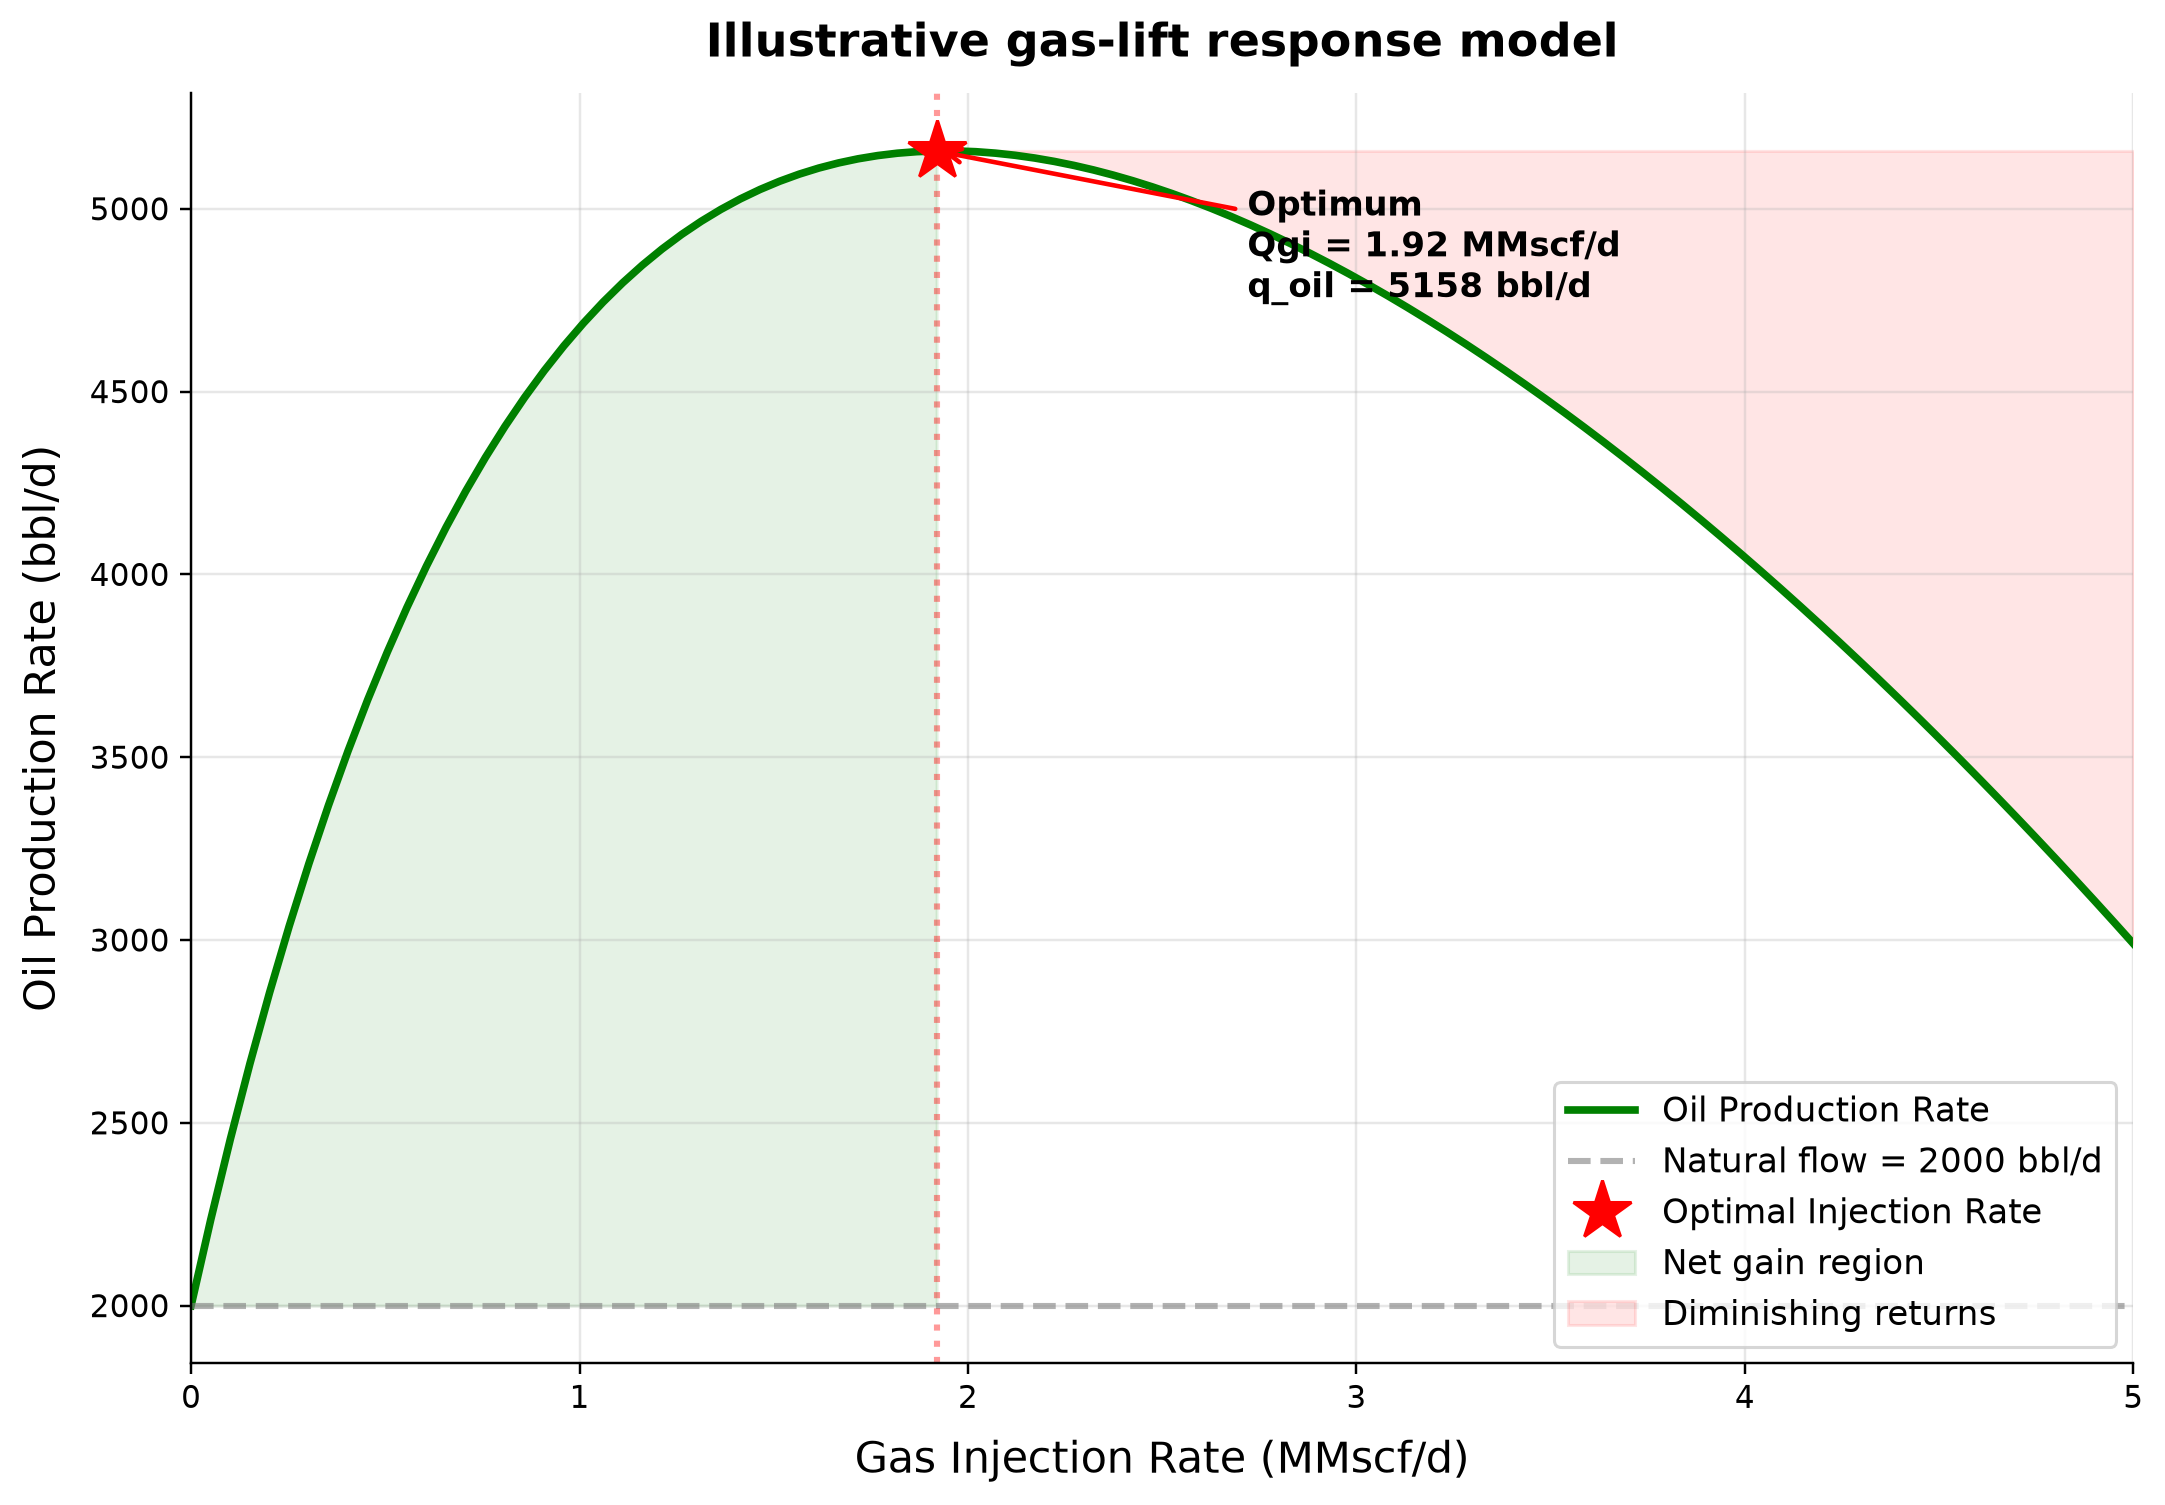

In [6]:
# Conceptual gas lift performance curve
# Based on typical behavior: production increases then plateaus/decreases
gas_injection_rate = np.linspace(0, 5.0, 100)  # MMscf/d

# Production response model: q = q_natural + gain * (1 - exp(-k*Qgi)) - friction_loss * Qgi^2
q_natural = 2000.0  # Natural flow rate (bbl/d)
gain = 4000.0       # Maximum additional production
k = 1.2             # Response factor
friction_coeff = 120.0  # Friction penalty coefficient

q_oil = q_natural + gain * (1.0 - np.exp(-k * gas_injection_rate)) - friction_coeff * gas_injection_rate**2

# Find optimum
idx_opt = np.argmax(q_oil)
q_opt_inj = gas_injection_rate[idx_opt]
q_opt_oil = q_oil[idx_opt]

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(gas_injection_rate, q_oil, 'g-', linewidth=2.5, label='Oil Production Rate')
ax.axhline(y=q_natural, color='gray', linestyle='--', alpha=0.6, label=f'Natural flow = {q_natural:.0f} bbl/d')

# Mark optimum
ax.plot(q_opt_inj, q_opt_oil, 'r*', markersize=20, zorder=5, label='Optimal Injection Rate')
ax.axvline(x=q_opt_inj, color='red', linestyle=':', alpha=0.4)
ax.annotate(f'Optimum\nQgi = {q_opt_inj:.2f} MMscf/d\nq_oil = {q_opt_oil:.0f} bbl/d',
            xy=(q_opt_inj, q_opt_oil), xytext=(q_opt_inj + 0.8, q_opt_oil - 400),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

# Shade regions
ax.fill_between(gas_injection_rate[:idx_opt+1], q_natural, q_oil[:idx_opt+1],
                alpha=0.1, color='green', label='Net gain region')
ax.fill_between(gas_injection_rate[idx_opt:], q_oil[idx_opt:], q_oil[idx_opt],
                alpha=0.1, color='red', label='Diminishing returns')

ax.set_xlabel('Gas Injection Rate (MMscf/d)', fontsize=14)
ax.set_ylabel('Oil Production Rate (bbl/d)', fontsize=14)
ax.set_title('Illustrative gas-lift response model', fontsize=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 5.0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch05_fig03_gas_lift_optimization.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

**Executed-figure discussion.** Oil Production Rate spans 2000–5158 bbl/d across the plotted cases.

Injected gas reduces the hydrostatic density of the wellbore mixture while increasing friction and surface gas handling. Improved lift pressure does not by itself establish incremental oil production; a rate gain requires a coupled inflow solution and sufficient gas capacity. Optimize gas allocation using incremental oil or value per unit injection gas, including compression demand and total gas availability.


## Figure 4: Wellhead Pressure vs Flow Rate at Different Water Mole Fractions

Increasing water cut raises the hydrostatic head in the tubing (water is denser than oil/gas),
reducing the wellhead pressure for a given bottomhole pressure. This directly impacts
well deliverability.

Figure 4 saved.


ch05_well_performance_figures.ipynb:cell12:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


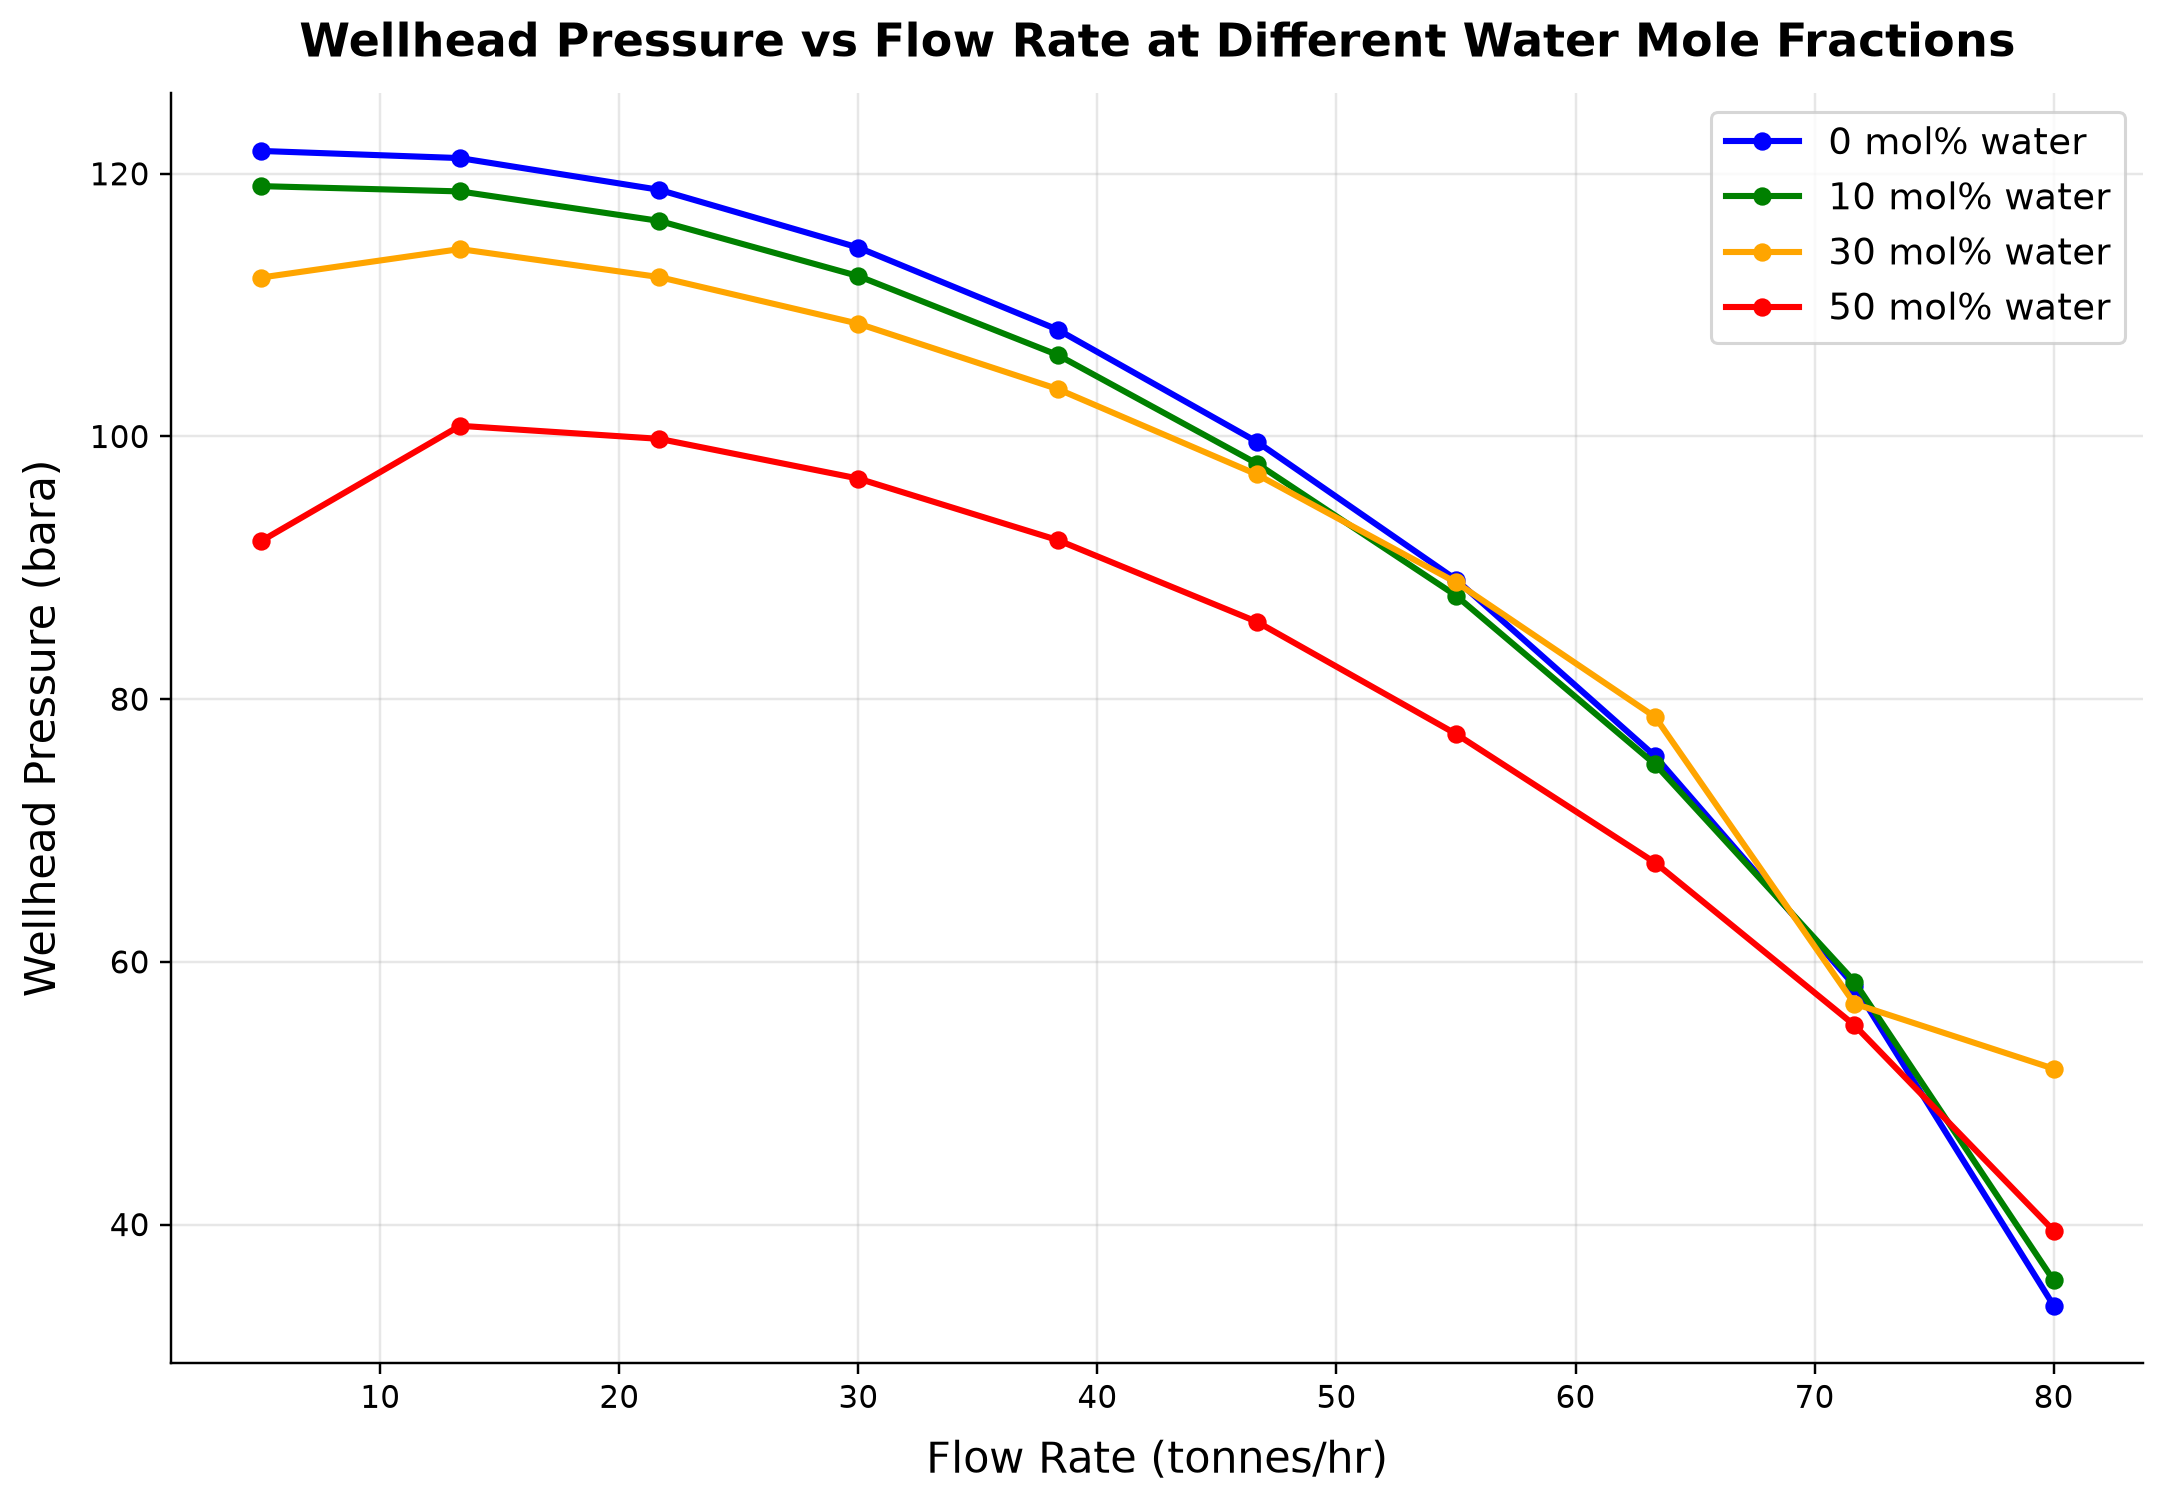

In [7]:
# Water mole-fraction scenarios (not standard-liquid water cut)
water_cuts = [0.0, 0.10, 0.30, 0.50]
wc_labels = ['0 mol% water', '10 mol% water', '30 mol% water', '50 mol% water']
wc_colors = ['blue', 'green', 'orange', 'red']
flow_rates_wc = np.linspace(5000, 80000, 10)  # kg/hr

fig, ax = plt.subplots(figsize=(10, 7))

for wc, label, color in zip(water_cuts, wc_labels, wc_colors):
    pwh_values = []
    valid_rates = []

    for rate in flow_rates_wc:
        try:
            fluid = create_well_fluid(water_fraction=wc)
            feed = Stream("well feed", fluid)
            feed.setFlowRate(float(rate), "kg/hr")
            feed.setTemperature(273.15 + 80.0, "K")
            feed.setPressure(200.0, "bara")

            pipe = PipeBeggsAndBrills("wellbore", feed)
            pipe.setPipeWallRoughness(2.5e-5)
            pipe.setLength(2500.0)
            pipe.setElevation(2500.0)
            pipe.setDiameter(0.10)  # 4 inch

            process = ProcessSystem()
            process.add(feed)
            process.add(pipe)
            process.run()

            p_wh = pipe.getOutletStream().getPressure("bara")
            if p_wh > 1.0:
                pwh_values.append(p_wh)
                valid_rates.append(rate / 1000.0)
        except Exception:
            pass

    if valid_rates:
        ax.plot(valid_rates, pwh_values, f'-o', color=color, linewidth=2,
                markersize=5, label=label)

ax.set_xlabel('Flow Rate (tonnes/hr)', fontsize=14)
ax.set_ylabel('Wellhead Pressure (bara)', fontsize=14)
ax.set_title('Wellhead Pressure vs Flow Rate at Different Water Mole Fractions', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch05_fig04_watercut_effect.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

**Executed-figure discussion.** 0 mol% water: wellhead pressure spans 33.83–121.7 bara across the plotted cases. 10 mol% water: wellhead pressure spans 35.75–119.1 bara across the plotted cases.

Increasing water fraction changes mixture density, liquid holdup and friction while reducing the oil fraction of the produced stream. At a fixed total mass rate, oil production and available lifting margin can both deteriorate as water cut rises. Track oil, gas and water rates separately and recompute the coupled well operating point at each water-cut case.


## Summary

This chapter demonstrated key well performance concepts:

1. **VLP Curves**: Larger tubing diameters reduce friction losses but too-large tubing can lead to liquid loading. NeqSim's Beggs & Brill model captures the multiphase flow physics accurately.

2. **Operating Point**: The intersection of IPR and VLP defines the natural operating point. Changes in reservoir pressure, tubing size, or wellhead pressure shift this point.

3. **Gas Lift**: There is an optimal gas injection rate that maximizes production. Beyond this point, additional gas increases friction more than it reduces hydrostatic head.

4. **Water Cut Effect**: Increasing water production dramatically reduces wellhead pressure due to the higher density of water. This is a critical consideration for late-life field management.

### Key Takeaway
NeqSim's `PipeBeggsAndBrills` model provides rigorous multiphase flow calculations essential
for well performance analysis. Combined with thermodynamic fluid models, it enables accurate
prediction of well deliverability under various operating scenarios.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                              Figure  Panel                       Series               Output / unit  Minimum  Maximum  Finite points  Missing points
           ch05_fig01_vlp_curves.png      1         Tubing ID = 3.0 inch    Wellhead Pressure (bara)  33.9224   122.01              6               0
           ch05_fig01_vlp_curves.png      1         Tubing ID = 4.0 inch    Wellhead Pressure (bara)  33.8296  121.739             12               0
           ch05_fig01_vlp_curves.png      1         Tubing ID = 5.0 inch    Wellhead Pressure (bara)   94.232  122.372             12               0
      ch05_fig02_operating_point.png      1 NeqSim tubing + reservoir PI    Wellhead pressure (bara)  7.80788  159.148             13               6
      ch05_fig02_operating_point.png      1  Wellhead boundary (50 bara)    Wellhead pressure (bara)       50       50              2               0
      ch05_fig02_operating_point.png      1                      Curve 3    Wellhead pressure (bara)